In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01010
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  289.67710964087456
RUN  2 , total integrated cost =  115.20102453181528
RUN  3 , total integrated cost =  46.785382325155105
RUN  4 , total integrated cost =  42.46392792994703
RUN  5 , total integrated cost =  36.49228762038061
RUN  6 , total integrated cost =  25.35366896854525
RUN  7 , total integrated cost =  25.27287749201372
RUN  8 , total integrated cost =  24.47604426457681
RUN  9 , total integrated cost =  24.047506977842644
RUN  10 , total integrated cost =  24.033547344195263
RUN  11 , total integrated cost =  23.78173915338486
RUN  12 , total integrated cost =  23.65366528851202
RUN  13 , total integrated cost =  23.648714220317018
RUN  14 , total integrated cost =  23.614698133277628
RUN  15 , total integrated cost =  23.507073405421732
RU

ERROR:root:Problem in initial value trasfer


RUN  140 , total integrated cost =  19.10461038396112
State only changes marginally.
Control only changes marginally.
RUN  144 , total integrated cost =  19.104610383934137
Improved over  144  iterations in  14.153245249763131  seconds by  99.8564797162929  percent.
Problem in initial value trasfer:  Vmean_exc -56.67235164117613 -56.67235167217291
weight =  6967.656237642567
set cost params:  1.0 6967.656237642567 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13031.12119906973
Gradient descend method:  None
RUN  1 , total integrated cost =  11704.564960169155
RUN  2 , total integrated cost =  11702.58935400413
RUN  3 , total integrated cost =  11702.239544354705
RUN  4 , total integrated cost =  11701.426383261398
RUN  5 , total integrated cost =  11622.891570698057
RUN  6 , total integrated cost =  11583.352439702721
RUN  7 , total integrated cost =  11583.256414566338
RUN  8 , total integrated cost =  11583.25063842968
RUN  9 , total integrated cost =  1

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  11583.250275588698
RUN  14 , total integrated cost =  11583.25027558862
RUN  15 , total integrated cost =  11583.250275588602
RUN  16 , total integrated cost =  11583.25027558859
RUN  17 , total integrated cost =  11583.25027558859
Control only changes marginally.
RUN  17 , total integrated cost =  11583.25027558859
Improved over  17  iterations in  0.40464380010962486  seconds by  11.110869904152992  percent.
Problem in initial value trasfer:  Vmean_exc -56.67182610387845 -56.671838956191166
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  211.18450052456944
RUN  2 , total integrated cost =  144.4249066500136
RUN  3 , total integrated cost =  77.2032232626254
RUN  4 , total integrated cost =  43.70027723330111
RUN  5 , total integrated cost =  42.26432712378733
RUN 

...

RUN  2 , total integrated cost =  33632.44328116743
RUN  3 , total integrated cost =  33632.44328116743
Control only changes marginally.
RUN  3 , total integrated cost =  33632.44328116743
Improved over  3  iterations in  0.12731967866420746  seconds by  4.413545158854504e-05  percent.
Problem in initial value trasfer:  Vmean_exc -68.2116823568976 -68.21173383058907
weight =  10.000004413547105
set cost params:  1.0 10.000004413547105 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33632.44328117371
Gradient descend method:  None
RUN  1 , total integrated cost =  33632.443281173706
RUN  2 , total integrated cost =  33632.443281173706
Control only changes marginally.
RUN  2 , total integrated cost =  33632.443281173706
Improved over  2  iterations in  0.10316725261509418  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -68.21168235689827 -68.21173383058974
-------  132 0.4500000000000001 0.8750000000000006
set cost par

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10117.573589110178
Control only changes marginally.
RUN  1 , total integrated cost =  10117.573589110178
Improved over  1  iterations in  0.04751386679708958  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10117.573589110178
Gradient descend method:  None
RUN  1 , total integrated cost =  10117.573589110178
Control only changes marginally.
RUN  1 , total integrated cost =  10117.573589110178
Improved over  1  iterations in  0.04572011157870293  seconds by  0.0  percent.
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768838654094
Gradient descend method:  None
RUN  1 , total integrated cost =  23430.768838598116
RUN  2 , total integrated cost =  23430.76883859811
RUN  3 , total integrated cost =  23430.76883859811
Control only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23430.76883859811
Control only changes marginally.
RUN  1 , total integrated cost =  23430.76883859811
Improved over  1  iterations in  0.05556356720626354  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.8389198225209 -73.83891989571526


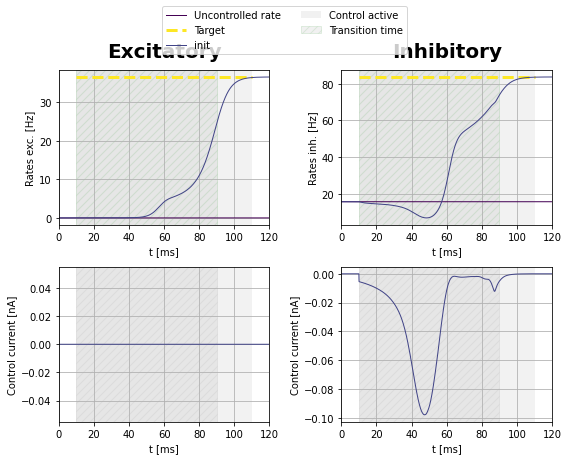

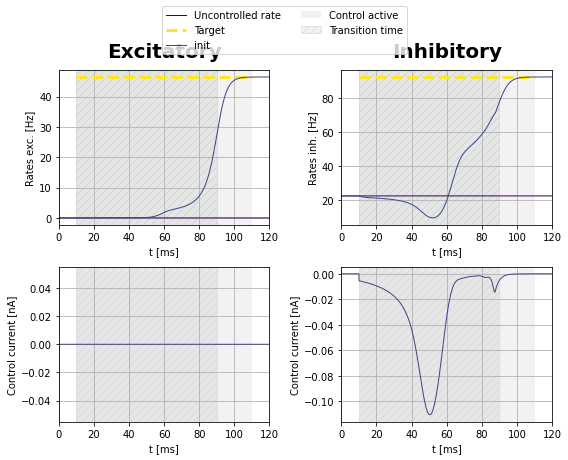

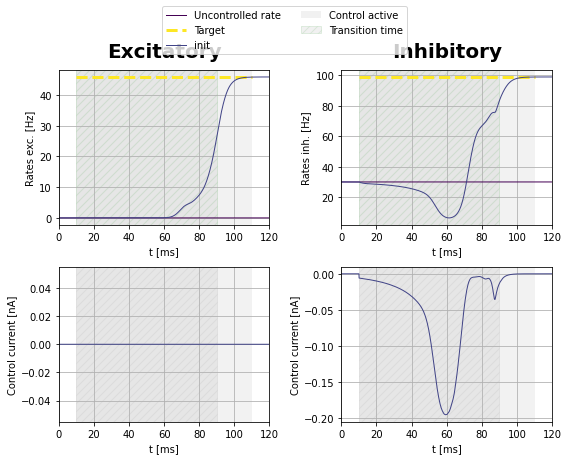

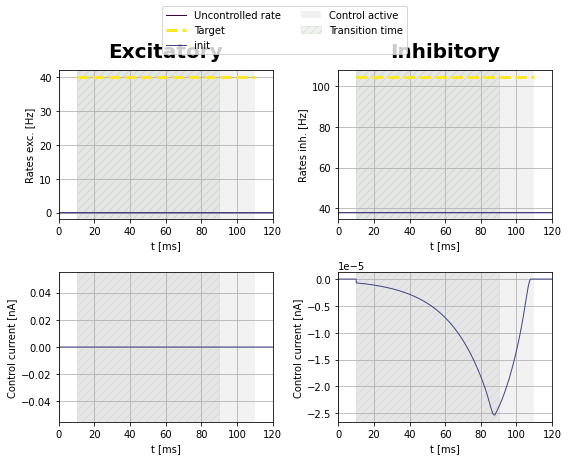

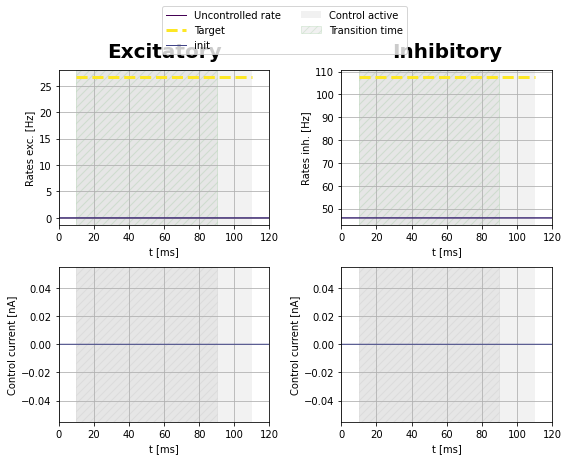

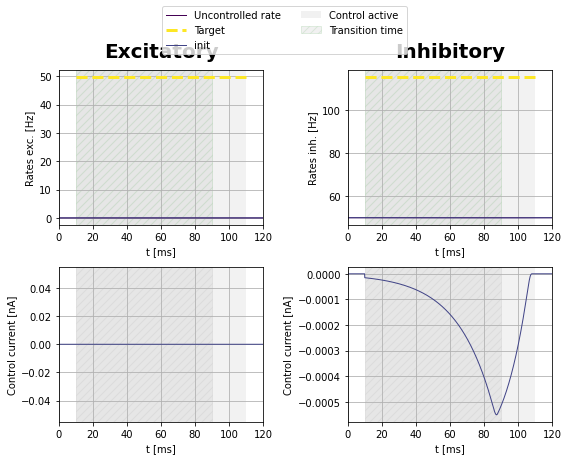

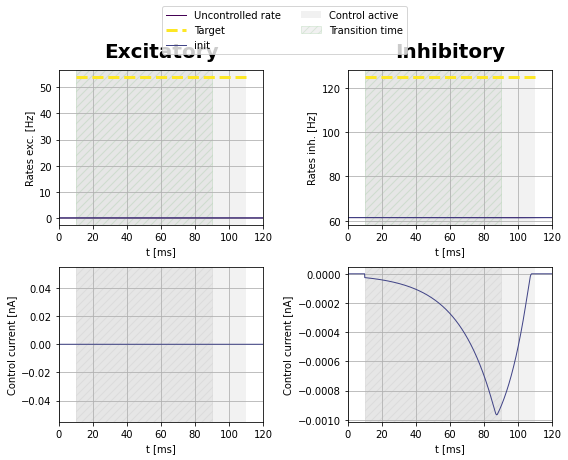

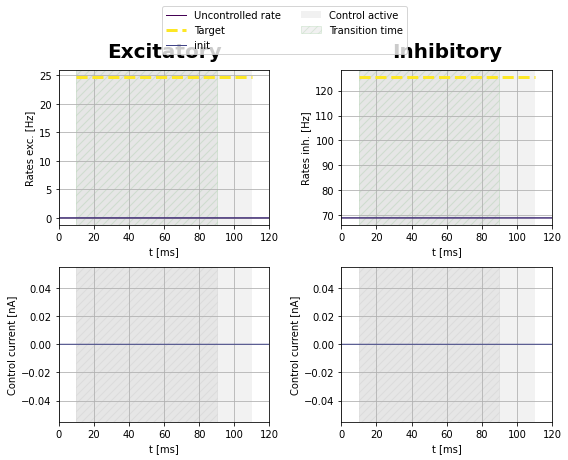

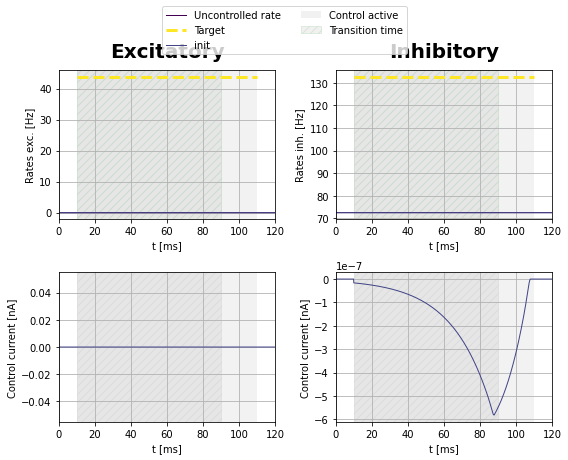

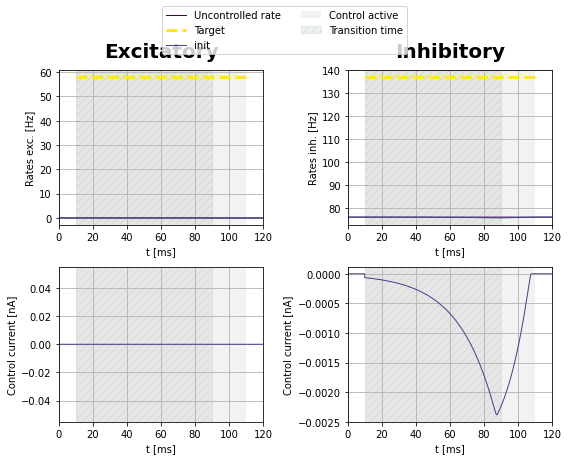

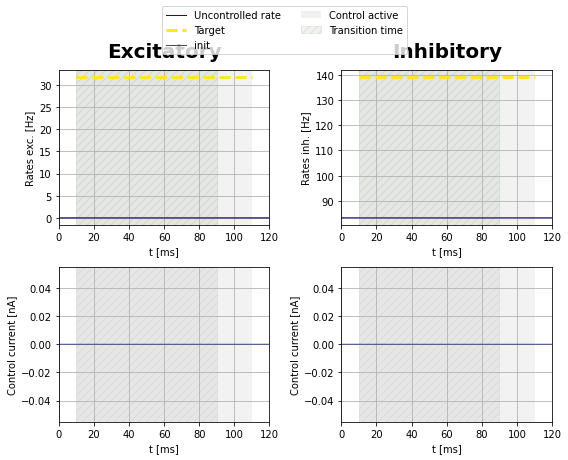

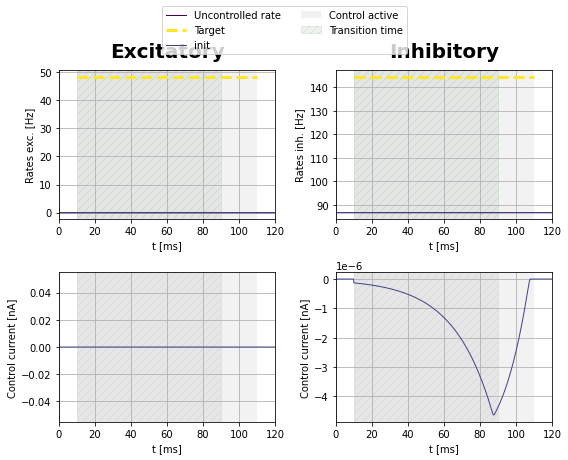

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
found solution for  22
-------

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  16137.019488206788
Control only changes marginally.
RUN  8 , total integrated cost =  16137.019488206788
Improved over  8  iterations in  0.21042005345225334  seconds by  0.3953354050619282  percent.
Problem in initial value trasfer:  Vmean_exc -73.72324063006913 -73.7232423287716
weight =  10.000000001026342
set cost params:  1.0 10.000000001026342 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019488206788
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019488206788
Control only changes marginally.
RUN  1 , total integrated cost =  16137.019488206788
Improved over  1  iterations in  0.05439356528222561  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.72324063006913 -73.7232423287716
-------  55 0.4250000000000001 0.6250000000000003
[0, 11, 22, 33] []
closest index  33
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  24742.028742082024
Control only changes marginally.
RUN  6 , total integrated cost =  24742.028742082024
Improved over  6  iterations in  0.1673014685511589  seconds by  0.2565097591035084  percent.
Problem in initial value trasfer:  Vmean_exc -70.77685863296838 -70.77688308886555
weight =  10.000000317725373
set cost params:  1.0 10.000000317725373 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24742.028742082046
Gradient descend method:  None
RUN  1 , total integrated cost =  24742.028742082046
Control only changes marginally.
RUN  1 , total integrated cost =  24742.028742082046
Improved over  1  iterations in  0.05870681442320347  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.77685863296838 -70.77688308886555
-------  77 0.4500000000000001 0.7000000000000004
found solution for  77
-------  88 0.5500000000000003 0.7250000000000004
[0, 11, 22, 33, 77] []
closest index  77
set cost params:  1.0 

...

RUN  30 , total integrated cost =  187.3344124481985
Control only changes marginally.
RUN  31 , total integrated cost =  187.3344124481985
Improved over  31  iterations in  0.7763759847730398  seconds by  62.69141573452989  percent.
Problem in initial value trasfer:  Vmean_exc -56.70209400909025 -56.70209405140807
weight =  1320.7412992015386
set cost params:  1.0 1320.7412992015386 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24525.002245755706
Gradient descend method:  None
RUN  1 , total integrated cost =  23851.67478528206
RUN  2 , total integrated cost =  23851.67478528206
Control only changes marginally.
RUN  2 , total integrated cost =  23851.67478528206
Improved over  2  iterations in  0.1043312456458807  seconds by  2.7454735935454266  percent.
Problem in initial value trasfer:  Vmean_exc -56.70208537496912 -56.702085737154775
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
found solution for  8

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  173.01074687950216
Control only changes marginally.
RUN  32 , total integrated cost =  173.01074687950214
Improved over  32  iterations in  0.7022622488439083  seconds by  65.55263492357871  percent.
Problem in initial value trasfer:  Vmean_exc -56.684056374869414 -56.68405645872185
weight =  932.7177519846236
set cost params:  1.0 932.7177519846236 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15949.078010005362
Gradient descend method:  None
RUN  1 , total integrated cost =  15446.812159353578
RUN  2 , total integrated cost =  15445.681521278635
RUN  3 , total integrated cost =  15445.631431349419
RUN  4 , total integrated cost =  15445.62263465166
RUN  5 , total integrated cost =  15445.620055195088
RUN  6 , total integrated cost =  15445.619066507355
RUN  7 , total integrated cost =  15445.6186796354
RUN  8 , total integrated cost =  15445.618474514185
RUN  9 , total integrated cost =  15445.618409209268
RUN  10 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  48 , total integrated cost =  15445.617886113343
Improved over  48  iterations in  1.020531453192234  seconds by  3.1566722764549837  percent.
Problem in initial value trasfer:  Vmean_exc -56.683881829862266 -56.683886667968274
-------  55 0.4250000000000001 0.6250000000000003
found solution for  55
-------  66 0.5250000000000001 0.6500000000000004
found solution for  66
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006
------------------------------------------------------------
-------------------- 3
------------------------------------------------------------
found solution:  [0, 11, 22, 33, 77, 88, 99, 110, 121, 132, 143, 55, 66]
no solution:  []

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  9803.074246845172
set cost params:  1.0 9803.074246845172 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.804067453498
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.80406745342
RUN  2 , total integrated cost =  5901.804067453417
RUN  3 , total integrated cost =  5901.804067453413
RUN  4 , total integrated cost =  5901.8040674534095


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  5901.804067453407
RUN  6 , total integrated cost =  5901.804067453407
Control only changes marginally.
RUN  6 , total integrated cost =  5901.804067453407
Improved over  6  iterations in  0.2721734866499901  seconds by  1.5489831639570184e-12  percent.
Problem in initial value trasfer:  Vmean_exc -56.630244660789565 -56.63010180009144
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  8006.209226653823
set cost params:  1.0 8006.209226653823 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13278.883115358458
Gradient descend method:  None
RUN  1 , total integrated cost =  13277.364265515702
RUN  2 , total integrated cost =  13277.33084494506
RUN  3 , total integrated cost =  13277.329424966458
RUN  4 , total integrated cost =  13277.32925379075
RUN  5 , total integrated cost =  13277.329247348238
RUN  6 , total integrated cost =  13277.329246994956
RUN  7 , total integrated cost =  13277.329246983492


ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  13277.329246982867
Control only changes marginally.
RUN  14 , total integrated cost =  13277.329246982867
Improved over  14  iterations in  0.34892634488642216  seconds by  0.011701800234945381  percent.
Problem in initial value trasfer:  Vmean_exc -56.671771540083554 -56.6717857086246
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  11020.819218106837
set cost params:  1.0 11020.819218106837 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21502.423493505714
Gradient descend method:  None
RUN  1 , total integrated cost =  21498.967686028653
RUN  2 , total integrated cost =  21498.902735098403
RUN  3 , total integrated cost =  21498.899907840012
RUN  4 , total integrated cost =  21498.89983386119
RUN  5 , total integrated cost =  21498.899707504253
RUN  6 , total integrated cost =  21498.89968919521
RUN  7 , total integrated cost =  21498.89968865771
RUN  8 , total integrated cost =  21498.899688631

...

RUN  0 , total integrated cost =  7073.149083167289
Gradient descend method:  None
RUN  1 , total integrated cost =  7073.149083167289
Control only changes marginally.
RUN  1 , total integrated cost =  7073.149083167289
Improved over  1  iterations in  0.07349186949431896  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62952104374642 -56.62954363784458
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
no convergence
weight =  69.76051118261294
set cost params:  1.0 69.76051118261294 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6034.270359256528
Gradient descend method:  None
RUN  1 , total integrated cost =  6034.270359256528
Control only changes marginally.
RUN  1 , total integrated cost =  6034.270359256528
Improved over  1  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23362.940922562088
RUN  2 , total integrated cost =  23362.940922562088
Control only changes marginally.
RUN  2 , total integrated cost =  23362.940922562088
Improved over  2  iterations in  0.13766917772591114  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.700531720116295 -56.700532173199136
[[True, True], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [False, False], [True, True], [True, False], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  11054.510827642473
set cost params:  1.0 11054.510827642473 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21563.22696133368
Gradient descend method:  None
RUN  1 , total integrat

ERROR:root:Problem in initial value trasfer



interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23362.940922562088
Gradient descend method:  None
RUN  1 , total integrated cost =  23362.940922562088
Control only changes marginally.
RUN  1 , total integrated cost =  23362.940922562088
Improved over  1  iterations in  0.08011309057474136  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700531720116295 -56.700532173199136
[[True, True], [True, True], [False, False], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  254.81661369838974
Gradient descend method:  None
RUN  1 , total integrated cost =  19.68895849286428
RUN  2 , total integrated cost =  19.607895299824058
RUN  3 , total integrated cost =  19.56080230683111
RUN  4 , total integrated cost =  19.52003244937958
RUN  5 , total integrated cost =  19.502309995484804
RUN  6 , total integrated cost =  19.483247625124235
RUN  7 , total integrated cost =  19.4738379164283
RUN  8 , total integrated cost =  19.456142237351273
RUN  9 , total integrated cost =  19.439491213767297
RUN  10 , total integrated cost =  19.438236962820763
RUN  11 , total integrated cost =  19.431555548852046
RUN  12 , total integrated cost =  19.422856038790464
RUN  13 , total integrated cost =  19.421808400639083
RUN  14 , total integrated cost =  19.415602873084215
RUN  15 , total integrated cost =  19.404960019093746


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  69 , total integrated cost =  19.386417551376084
Improved over  69  iterations in  4.421579115092754  seconds by  92.39201193752517  percent.
Problem in initial value trasfer:  Vmean_exc -56.67234787161273 -56.67234831249448
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  177.27659581256245
Gradient descend method:  HS
RUN  1 , total integrated cost =  172.46475615800608
RUN  2 , total integrated cost =  170.58448964924452
RUN  3 , total integrated cost =  166.62442616256916
RUN  4 , total integrated cost =  164.08978743246595
RUN  5 , total integrated cost =  163.91661865265365
RUN  6 , total integrated cost =  160.9725143951058
RUN  7 , total integrated cost =  159.78428303977066
RUN  8 , total integrated cost =  157.6589144898285
RUN  9 , total integrated cost =  156.55710901979901
RUN  10 , total integrated cost =  156.42252727687102
RUN  11 , total integrated cost =  154.875

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  740 , total integrated cost =  103.59373190931447
Improved over  740  iterations in  53.66354462876916  seconds by  41.56378543118806  percent.
Problem in initial value trasfer:  Vmean_exc -56.67235147740899 -56.672351536581104
weight =  12848.653666872182
set cost params:  1.0 12848.653666872182 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13295.548429421442
Gradient descend method:  None
RUN  1 , total integrated cost =  13144.190138819216
RUN  2 , total integrated cost =  13138.03109802058
RUN  3 , total integrated cost =  13132.220194001513
RUN  4 , total integrated cost =  13115.61152859653
RUN  5 , total integrated cost =  13103.237816974906
RUN  6 , total integrated cost =  13101.286436741166
RUN  7 , total integrated cost =  13099.753760656626
RUN  8 , total integrated cost =  13097.944144824873
RUN  9 , total integrated cost =  13084.452275147192
RUN  10 , total integrated cost =  13075.137681505514
RUN  11 ,

...

RUN  1000 , total integrated cost =  116.97191383236633
RUN  1000 , total integrated cost =  116.97191383236633
Improved over  1000  iterations in  65.78721580095589  seconds by  45.62479140797178  percent.
Problem in initial value trasfer:  Vmean_exc -56.70054717702404 -56.70054703379154
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6503.798356115172
Gradient descend method:  HS
RUN  1 , total integrated cost =  6463.714072638785
RUN  2 , total integrated cost =  6353.6391648996205
RUN  3 , total integrated cost =  6291.898742628633
RUN  4 , total integrated cost =  6216.265356297022
RUN  5 , total integrated cost =  6151.575115261803
RUN  6 , total integrated cost =  6077.601734551843
RUN  7 , total integrated cost =  5889.837336007284
RUN  8 , total integrated cost =  5820.370582393547
RUN  9 , total integrated cost =  5818.047080359132
RUN  10 , total integrated cost =  5762.344559579471
RUN  11 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  88 , total integrated cost =  4552.5089273259955
Improved over  88  iterations in  6.732394199818373  seconds by  30.00230514456962  percent.
Problem in initial value trasfer:  Vmean_exc -56.70054864793474 -56.70054841526184
weight =  513.6781524801229
set cost params:  1.0 513.6781524801229 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23382.987196594837
Gradient descend method:  None
RUN  1 , total integrated cost =  23254.769611359192
RUN  2 , total integrated cost =  23189.699489152987
RUN  3 , total integrated cost =  23058.01087713661
RUN  4 , total integrated cost =  22991.598547097656
RUN  5 , total integrated cost =  21683.48495962565
RUN  6 , total integrated cost =  21636.36376718312
RUN  7 , total integrated cost =  21592.443796082076
RUN  8 , total integrated cost =  21535.58855036803
RUN  9 , total integrated cost =  21402.30289597207
RUN  10 , total integrated cost =  20939.155250862706
RUN  11 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  94 , total integrated cost =  5863.239763847679
Improved over  94  iterations in  5.849508449435234  seconds by  74.92518935005226  percent.
Problem in initial value trasfer:  Vmean_exc -56.70054840200102 -56.70054826599263


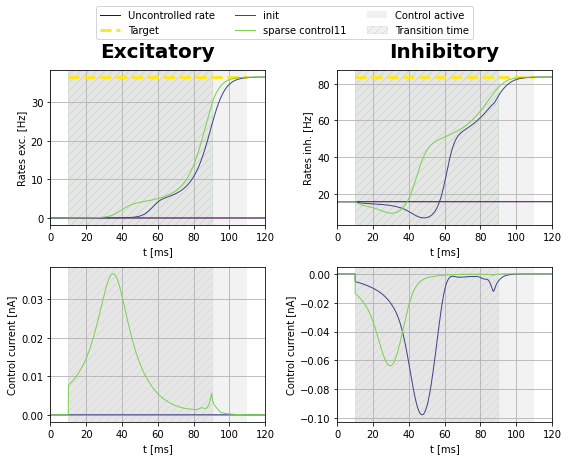

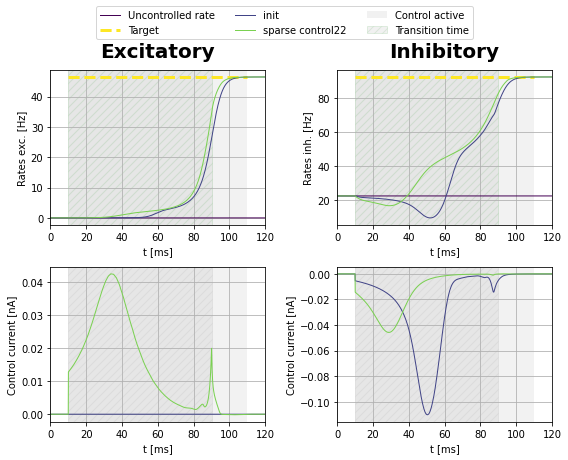

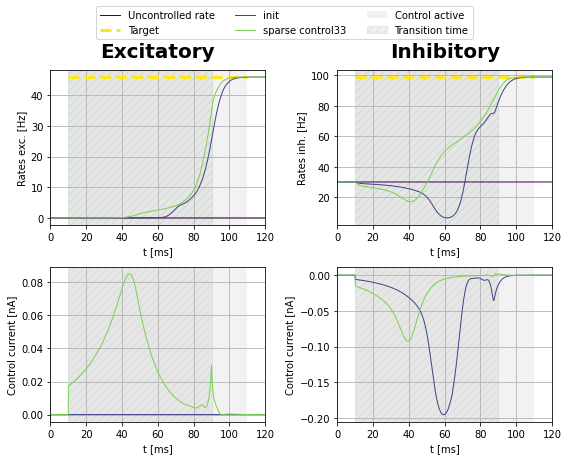

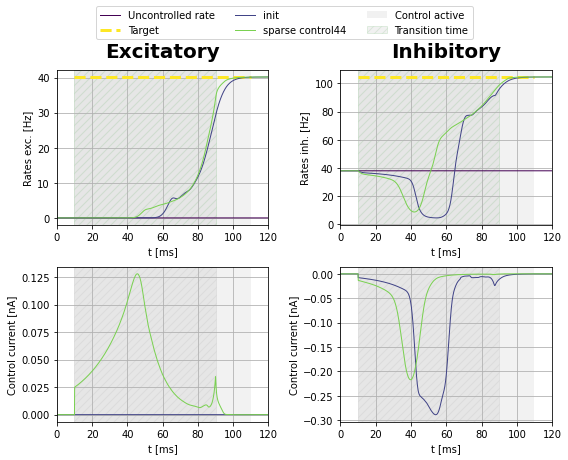

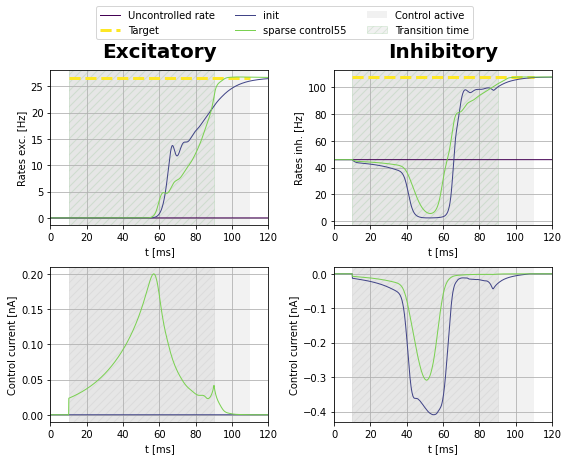

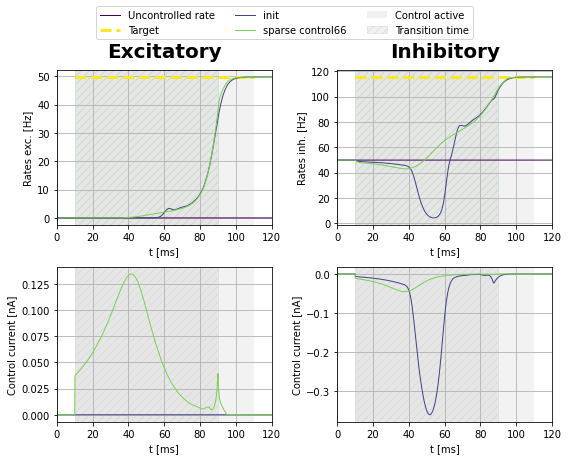

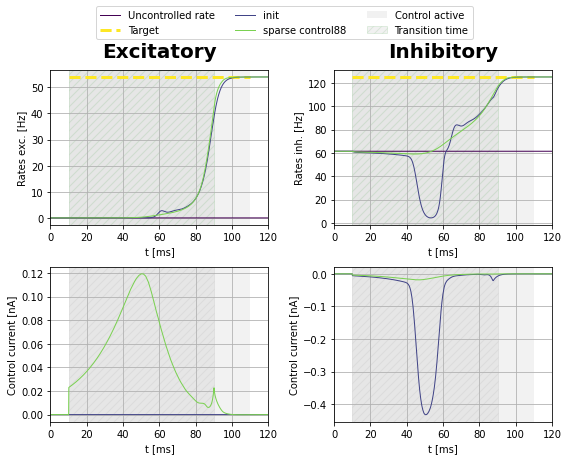

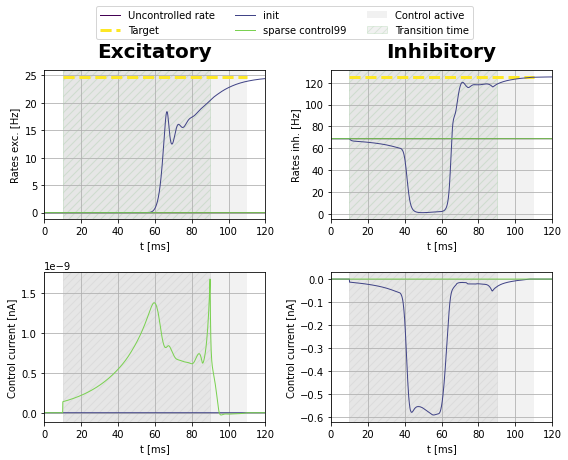

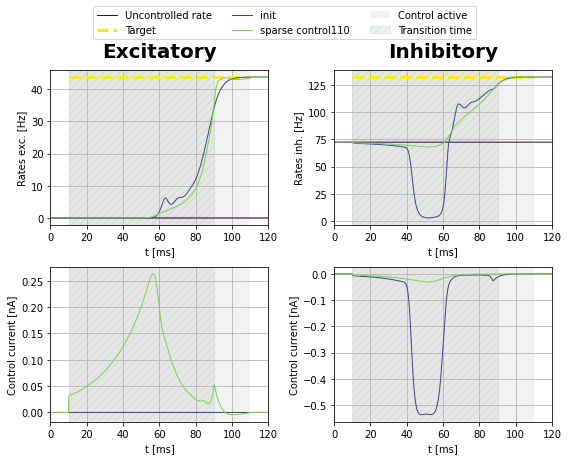

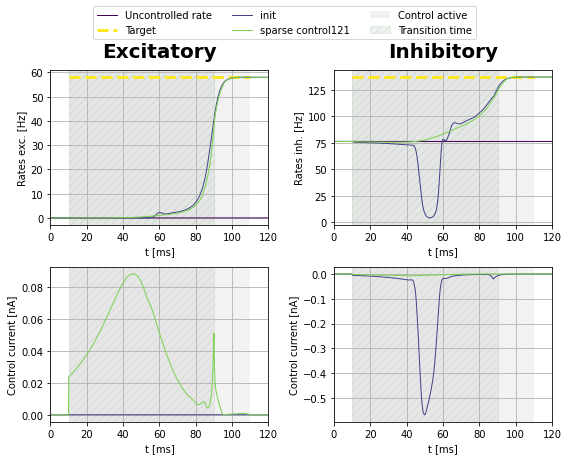

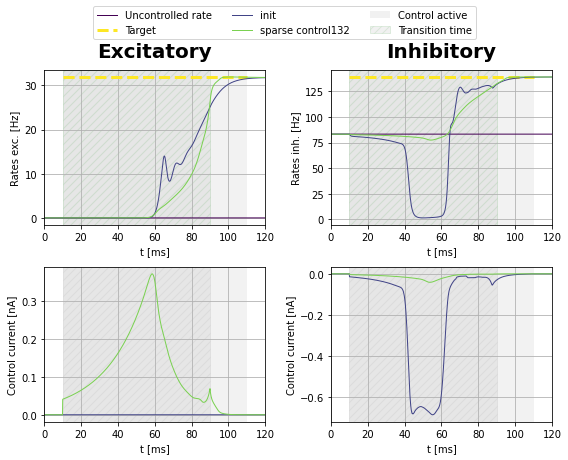

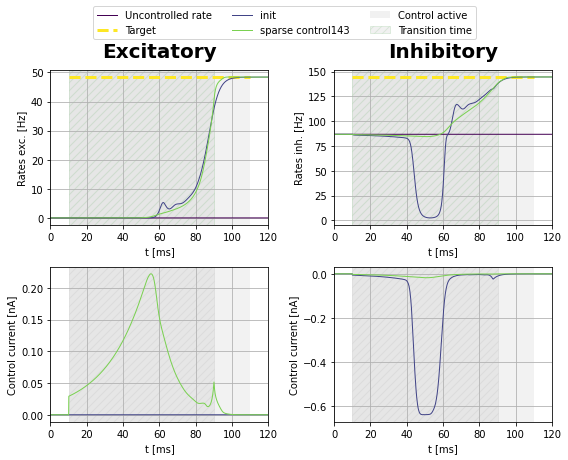

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  13079.862910804693
set cost params:  1.0 13079.862910804693 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13309.367888197592
Gradient descend method:  None
RUN  1 , total integrated cost =  13309.359024479962
RUN  2 , total integrated cost =  13309.359024479945
RUN  3 , total integrated cost =  13309.359024479938


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  13309.359024479938
Control only changes marginally.
RUN  4 , total integrated cost =  13309.359024479938
Improved over  4  iterations in  0.6268723122775555  seconds by  6.659758547300498e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.672166876893435 -56.672171185989384
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  23045.393219867692
set cost params:  1.0 23045.393219867692 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21562.306176060436
Gradient descend method:  None
RUN  1 , total integrated cost =  21562.30170096469
RUN  2 , total integrated cost =  21562.300622199782
RUN  3 , total integrated cost =  21562.30052719672
RUN  4 , total integrated cost =  21562.300514392315
RUN  5 , total integrated cost =  21562.300506494026
RUN  6 , total integrated cost =  21562.300502622813
RUN  7 , total integrated cost =  21562.30050096951
RUN  8 , total integrated cost =  21562.3005002343

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  21562.30049980135
RUN  18 , total integrated cost =  21562.30049980135
Control only changes marginally.
RUN  18 , total integrated cost =  21562.30049980135
Improved over  18  iterations in  1.7809243518859148  seconds by  2.6324916461817338e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.6983500747189 -56.69835190760012
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  6601.908970274854
set cost params:  1.0 6601.908970274854 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21064.88565195582
Gradient descend method:  None
RUN  1 , total integrated cost =  21064.878885473554
RUN  2 , total integrated cost =  21064.878882299523
RUN  3 , total integrated cost =  21064.878882294473
RUN  4 , total integrated cost =  21064.878882294397


...

RUN  1 , total integrated cost =  23419.41367677054
RUN  2 , total integrated cost =  23419.41367677054
Control only changes marginally.
RUN  2 , total integrated cost =  23419.41367677054
Improved over  2  iterations in  0.39528308995068073  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.70053940227865 -56.70053957720429
--------------- 10
[[True, True], [True, True], [True, True], [True, False], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23419.413676770542
RUN  2 , total integrated cost =  23419.413676770542
Control only changes marginally.
RUN  2 , total integrated cost =  23419.413676770542
Improved over  2  iterations in  0.38283522240817547  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.70053940227865 -56.70053957720429
--------------- 11
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66

ERROR:root:Problem in initial value trasfer


 23419.413676770542
Control only changes marginally.
RUN  1 , total integrated cost =  23419.413676770542
Improved over  1  iterations in  0.20025058090686798  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70053940227865 -56.70053957720429
--------------- 12
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.77

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  60.398001990676846
Gradient descend method:  None
RUN  1 , total integrated cost =  1.1041367376900824
RUN  2 , total integrated cost =  1.1028070694794627
RUN  3 , total integrated cost =  1.1027825737577024
RUN  4 , total integrated cost =  1.1027301618922998
RUN  5 , total integrated cost =  1.1022831790421543
RUN  6 , total integrated cost =  1.1021389964748025
RUN  7 , total integrated cost =  1.1021199596681786
RUN  8 , total integrated cost =  1.101799118178389
RUN  9 , total integrated cost =  1.1011008026545792
RUN  10 , total integrated cost =  1.1010726595359488
RUN  11 , total integrated cost =  1.101036143836415
RUN  12 , total integrated cost =  1.100458844073065
RUN  13 , total integrated cost =  1.100244590649923
RUN  14 , total integrated cost =  1.100227070131589
RUN  15 , total integrated cost =  1.0999267892547497
R

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  1.0619058757065374
Control only changes marginally.
RUN  43 , total integrated cost =  1.0619058757065356
Improved over  43  iterations in  0.9690325241535902  seconds by  98.24181952927772  percent.
Problem in initial value trasfer:  Vmean_exc -56.672326557162286 -56.67232732588143
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  113.0585245147014
Gradient descend method:  None
RUN  1 , total integrated cost =  1.03903356725521
RUN  2 , total integrated cost =  1.0197503095543146
RUN  3 , total integrated cost =  1.0197496248804296


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  1.0197496141170341
RUN  5 , total integrated cost =  1.01974961362422
RUN  6 , total integrated cost =  1.0197496136075859
RUN  7 , total integrated cost =  1.019749613607074
RUN  8 , total integrated cost =  1.0197496136070643
RUN  9 , total integrated cost =  1.019749613607062
RUN  10 , total integrated cost =  1.0197496136070607
RUN  11 , total integrated cost =  1.0197496136070607
Control only changes marginally.
RUN  11 , total integrated cost =  1.0197496136070607
Improved over  11  iterations in  0.2846070844680071  seconds by  99.09803385637281  percent.
Problem in initial value trasfer:  Vmean_exc -56.69836950444936 -56.69837065758555
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  90.65008807633187
Gradient descend method:  None
RUN  1 , total integrated cost =  3.3782426896695816
RUN  2 , total integrated cost =  3.3642748131636333
RUN  3 

...

RUN  30 , total integrated cost =  3.157996404257149
Control only changes marginally.
RUN  34 , total integrated cost =  3.13887672170445
Improved over  34  iterations in  0.7957866583019495  seconds by  98.92514914137574  percent.
Problem in initial value trasfer:  Vmean_exc -56.70341405555455 -56.70341616468379
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  47.685755227624476
Gradient descend method:  None
RUN  1 , total integrated cost =  33.91473072044387
RUN  2 , total integrated cost =  33.91262868222943
RUN  3 , total integrated cost =  33.91243242354586
RUN  4 , total integrated cost =  33.912336882326414
RUN  5 , total integrated cost =  33.912191614273944
RUN  6 , total integrated cost =  33.911054355969064
RUN  7 , total integrated cost =  33.8827252189446
RUN  8 , total integrated cost =  33.87492185714272
RUN  9 , total integrated cost =  33.874674017410726
RUN  10 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  83 , total integrated cost =  33.47955425618104
Improved over  83  iterations in  1.7032839599996805  seconds by  29.79128862200288  percent.
Problem in initial value trasfer:  Vmean_exc -56.65272289771545 -56.65271612373636
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  116.52523086439847
Gradient descend method:  None
RUN  1 , total integrated cost =  13.64867908195594
RUN  2 , total integrated cost =  13.63611522805415
RUN  3 , total integrated cost =  13.63098747285773
RUN  4 , total integrated cost =  13.62105703454609
RUN  5 , total integrated cost =  13.602731543896457
RUN  6 , total integrated cost =  13.60007340208572
RUN  7 , total integrated cost =  13.190915871320062


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  13.190915871320062
Control only changes marginally.
RUN  8 , total integrated cost =  13.190915871320062
Improved over  8  iterations in  0.21170136891305447  seconds by  88.67977709765668  percent.
Problem in initial value trasfer:  Vmean_exc -56.70054501686347 -56.7005450844748


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0619058757065356
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0619058757065356
Control only changes marginally.
RUN  1 , total integrated cost =  1.0619058757065356
Improved over  1  iterations in  0.06411501578986645  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.672326557162286 -56.67232732588143
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0197496136070607
Gradient descend method:  None
RUN  1 , total integrat

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.3642565218309564
Control only changes marginally.
RUN  1 , total integrated cost =  3.3642565218309564
Improved over  1  iterations in  0.06812955997884274  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69738683104011 -56.69738553041181
-------  44 0.47500000000000014 0.5750000000000003
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.573081498581614
Gradient descend method:  None
RUN  1 , total integrated cost =  9.573081498581614
Control only changes marginally.
RUN  1 , total integrated cost =  9.573081498581614
Improved over  1  iterations in  0.06799213029444218  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68403548629623 -56.684037110338345
-------  55 0.4250000000000001 0.6250000000000003
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24.7496275260

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6.161707305482393
Control only changes marginally.
RUN  1 , total integrated cost =  6.161707305482393
Improved over  1  iterations in  0.06616849079728127  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.702096344265684 -56.70209627184969
-------  88 0.5500000000000003 0.7250000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.1373254774121
Gradient descend method:  None
RUN  1 , total integrated cost =  5.1373254774121
Control only changes marginally.
RUN  1 , total integrated cost =  5.1373254774121
Improved over  1  iterations in  0.063879469409585  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70419313895474 -56.704193213184425
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  Tru

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.13887672170445
Control only changes marginally.
RUN  1 , total integrated cost =  3.13887672170445
Improved over  1  iterations in  0.06420798413455486  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70341405555455 -56.70341616468379
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33.47955425618104
Gradient descend method:  None
RUN  1 , total integrated cost =  33.47955425618104
Control only changes marginally.
RUN  1 , total integrated cost =  33.47955425618104
Improved over  1  iterations in  0.06716180220246315  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65272289771545 -56.65271612373636
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.19091587132006

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
